# **Customer Churn Prediction using Machine Learning**
# Course: BAN644/BAN744

## Objective
This project aims to predict customer churn using machine learning techniques and identify key factors affecting customer retention.

IMPORT LIBRARIES

In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from imblearn.over_sampling import SMOTE

## LOAD DATA

In [39]:
df = pd.read_csv('/content/Telco-Customer-Churn by Kakon.csv')

## DATA OVERVIEW

In [40]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.shape

(7043, 21)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
df.duplicated().sum()

np.int64(0)

## DATA CLEANING

In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [46]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [47]:
df.dropna(inplace=True)

In [48]:
df_original = df.copy()

## EDA

Churn Distribution

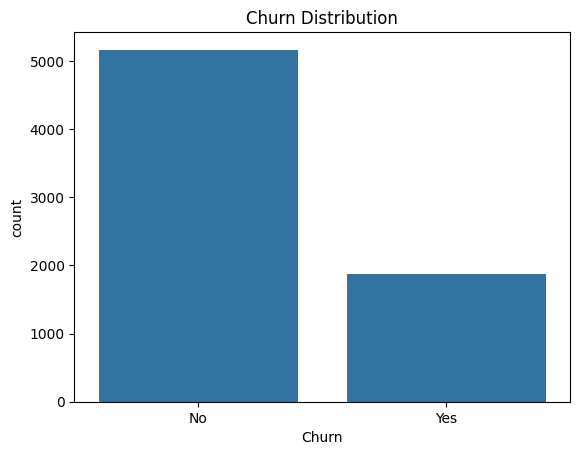

In [49]:
sns.countplot(x='Churn', data=df_original)
plt.title('Churn Distribution')
plt.show()

Contract vs Churn

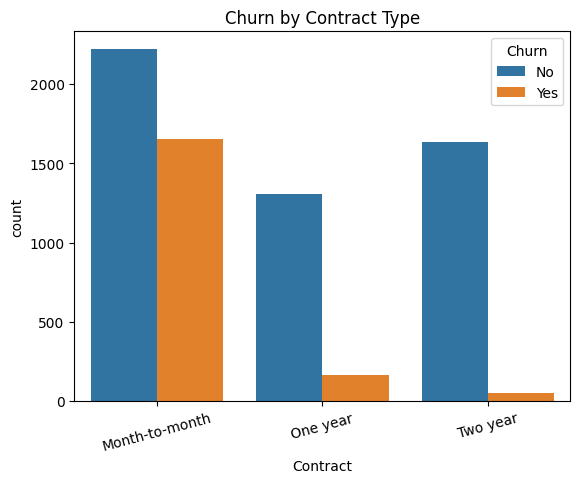

In [50]:
sns.countplot(x='Contract', hue='Churn', data=df_original)
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

Monthly Charges

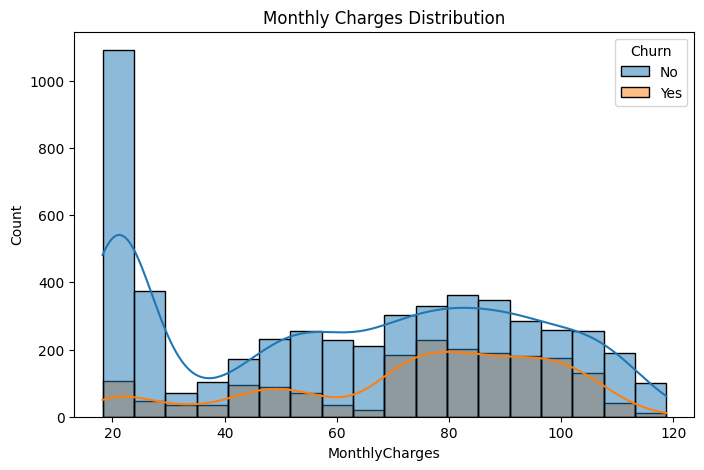

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_original,
    x='MonthlyCharges',
    hue='Churn',
    kde=True
)

plt.title('Monthly Charges Distribution')
plt.show()

Tenure vs Churn

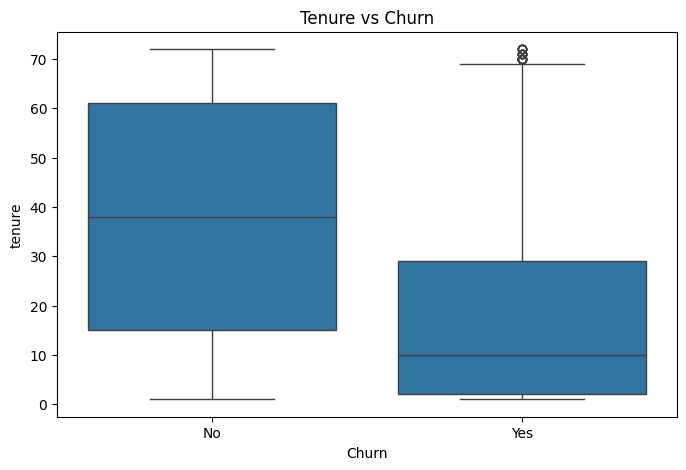

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df_original
)

plt.title('Tenure vs Churn')
plt.show()

ENCODING TARGET

In [53]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

ONE HOT ENCODING

In [54]:
df = pd.get_dummies(df, drop_first=True)

CORRELATION HEATMAP

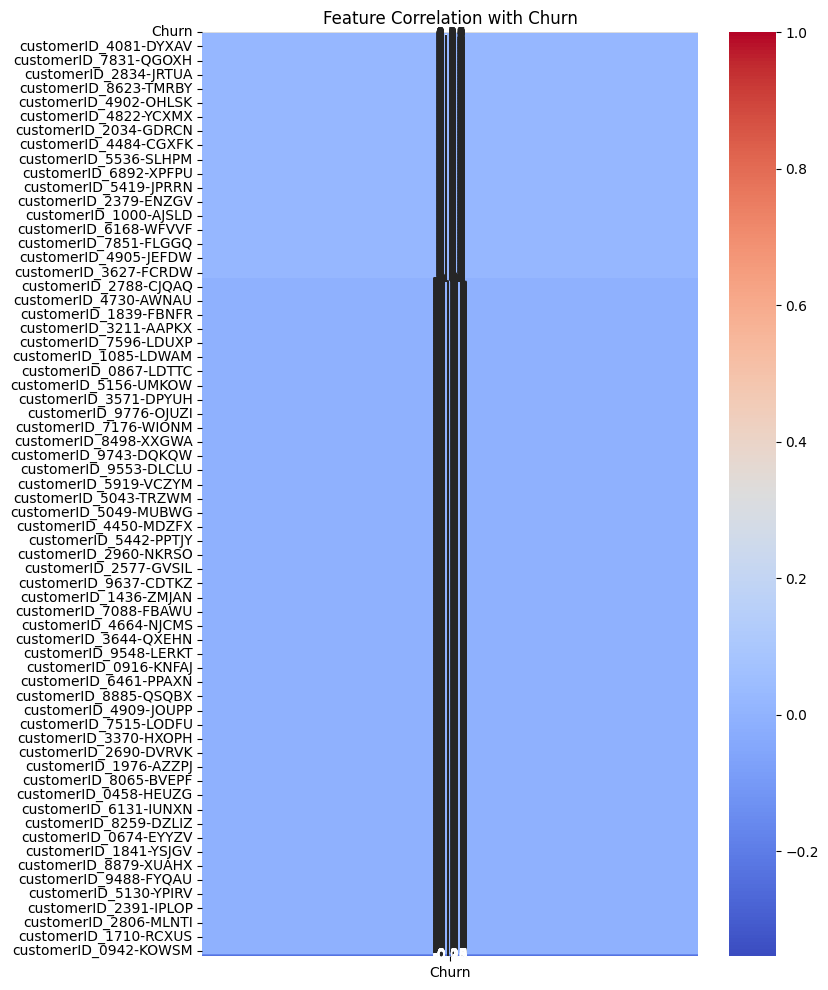

In [55]:
plt.figure(figsize=(8,12))

correlation = df.corr()[['Churn']].sort_values(by='Churn', ascending=False)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Feature Correlation with Churn')
plt.show()

SPLIT DATA

In [56]:
X = df.drop('Churn', axis=1)
y = df['Churn']

FEATURE SELECTION

In [57]:
selector = RandomForestClassifier(random_state=42)

selector.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
3,TotalCharges,0.102766
1,tenure,0.097854
2,MonthlyCharges,0.079830
7041,InternetService_Fiber optic,0.022697
7059,PaymentMethod_Electronic check,0.022369
7056,Contract_Two year,0.021595
7044,OnlineSecurity_Yes,0.021191
7055,Contract_One year,0.019909
7050,TechSupport_Yes,0.019539
7057,PaperlessBilling_Yes,0.018015


TRAIN TEST SPLIT

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

SCALING

In [59]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SMOTE

In [60]:
sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(
    X_train_scaled,
    y_train
)

LOGISTIC REGRESSION

In [61]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

LOGISTIC PREDICTION

In [62]:
y_pred_lr = lr.predict(X_test_scaled)

LOGISTIC EVALUATION

In [63]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(lr_accuracy)

0.7846481876332623


In [64]:
print(confusion_matrix(y_test, y_pred_lr))

[[952  81]
 [222 152]]


In [65]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.65      0.41      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



RANDOM FOREST

In [66]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=300, random_state=42)

RF PREDICTION

In [67]:
y_pred_rf = rf.predict(X_test_scaled)

RF EVALUATION

In [68]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(rf_accuracy)

0.7846481876332623


In [69]:
print(confusion_matrix(y_test, y_pred_rf))

[[901 132]
 [171 203]]


In [70]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.61      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



MODEL COMPARISON

In [71]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.784648
1,Random Forest,0.784648


In [72]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train_smote, y_train_smote)

best_rf = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


ROC CURVE

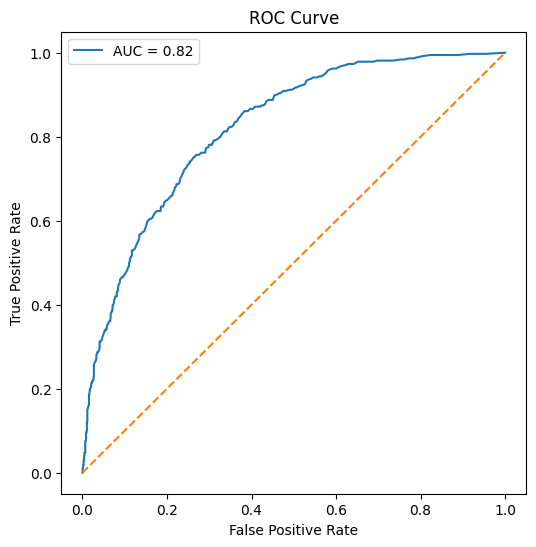

In [73]:
rf_probs = rf.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')
plt.legend()
plt.show()

FEATURE IMPORTANCE PLOT

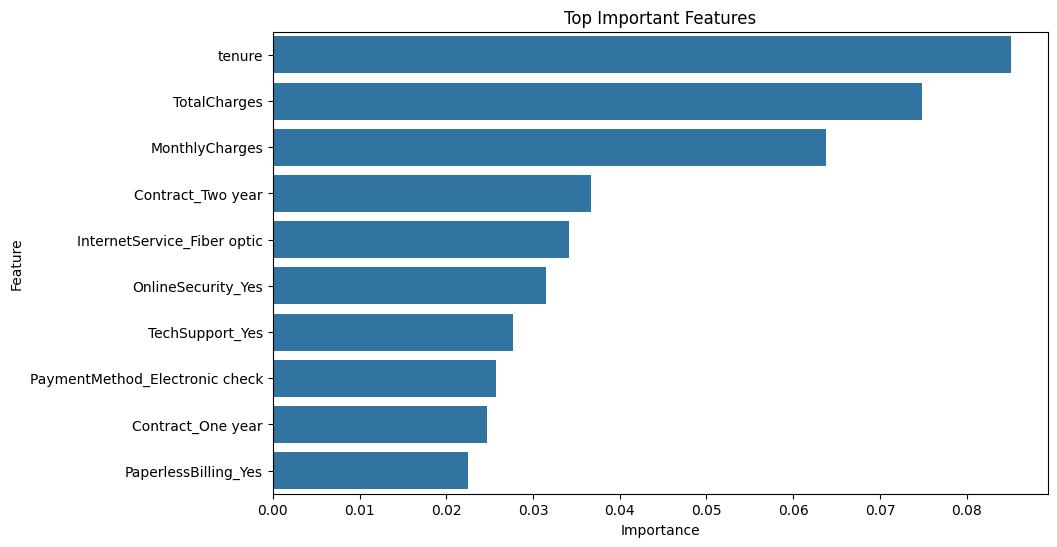

In [74]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp.head(10)
)

plt.title('Top Important Features')
plt.show()


## Business Insights & Recommendations
- Customers with month-to-month contracts are more likely to churn. The company should encourage long-term contracts through discounts or loyalty benefits.
- Customers with higher monthly charges show higher churn tendency. The company can introduce affordable pricing plans or personalized offers.
- Customers with shorter tenure are more likely to leave. The company should improve onboarding and customer engagement during the early months.
-Internet-related services significantly influence churn. Improving service quality and customer support may reduce churn.

LIMITATIONS

-The dataset may not represent all customer behaviors.

-Some variables may contain hidden bias.

-External factors affecting churn were not included.

-More advanced models could further improve accuracy.

## Conclusion
This project successfully developed machine learning models to predict customer churn. Among the tested models, Random Forest performed better than Logistic Regression. The analysis identified important factors affecting customer churn such as contract type, monthly charges, and tenure. The findings can help businesses take proactive measures to improve customer retention.

## AI Usage Disclosure
AI tools were used only for learning support, understanding concepts, debugging Python code, and improving explanations. All business interpretations, analysis, and conclusions were developed through personal understanding and evaluation.